# Demystifying Recurrent Neural Networks (RNNs)

Traditional neural networks struggle with one major thing: **context**. If you feed a standard feed-forward network the word "hello" one letter at a time, by the time it reaches the second "l", it has completely forgotten the "h" and the "e".

**Recurrent Neural Networks (RNNs)** solve this by introducing a "memory" mechanism called a **hidden state**. It passes information from previous steps to the current step.

## The Problem: Character-Level Language Modeling
We are going to build an RNN to predict the next character in a sequence. To keep our derivations clear, we will use a tiny toy dataset: training an RNN to spell the word **"hello"**.

When the network sees "h", we want it to predict "e". When it sees "e", we want it to predict "l", and so on.

In [3]:
import numpy as np
import torch

# 1. The Dataset
data = "hello"
chars = list(set(data)) # Unique characters: 'h', 'e', 'l', 'o'
data_size, vocab_size = len(data), len(chars)

print(f"Data has {data_size} characters, {vocab_size} unique.")

# 2. Creating dictionaries to map characters to integers and vice versa
char_to_ix = {ch: i for i, ch in enumerate(chars)}
ix_to_char = {i: ch for i, ch in enumerate(chars)}

print("Character mapping:", char_to_ix)

# 3. Preparing our inputs and targets
# Inputs:  'h', 'e', 'l', 'l'
# Targets: 'e', 'l', 'l', 'o'
inputs = [char_to_ix[ch] for ch in data[:-1]]
targets = [char_to_ix[ch] for ch in data[1:]]

Data has 5 characters, 4 unique.
Character mapping: {'l': 0, 'h': 1, 'e': 2, 'o': 3}


## Deriving the Forward Pass

An RNN has three main sets of weights:
1. $W_{xh}$: Weights connecting the input to the hidden layer.
2. $W_{hh}$: Weights connecting the previous hidden state to the current hidden state (the "memory").
3. $W_{hy}$: Weights connecting the hidden state to the output.

At any given time step $t$, the RNN does two things:

**1. Update the Hidden State:**
It combines the current input ($x_t$) with the previous hidden state ($h_{t-1}$) using a $tanh$ activation function to keep values between -1 and 1.
$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$

**2. Calculate the Output:**
It uses the new hidden state to calculate the raw output scores (logits).
$$y_t = W_{hy} h_t + b_y$$

To turn these raw scores into probabilities, we apply a **Softmax** function:
$$\hat{y}_t = \frac{\exp(y_t)}{\sum \exp(y_t)}$$

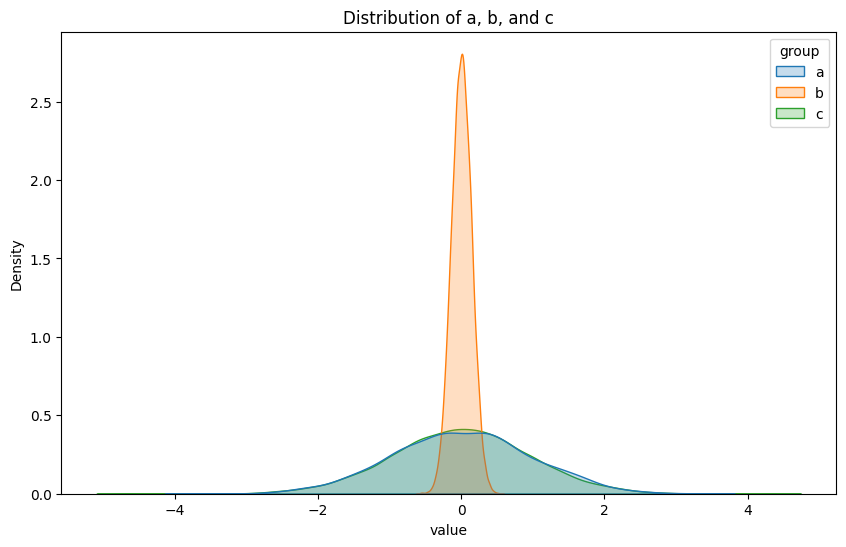

tensor(-0.0091) tensor(0.9591) tensor(0.9793)


In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

c = a@b

# 1. Combine your separate variables into a tidy DataFrame
df = pd.DataFrame({
    'value': list(a.detach().numpy().flatten()) + 
             list(b.detach().numpy().flatten()) + 
             list(c.detach().numpy().flatten()),
    'group': ['a'] * a.numel() + ['b'] * b.numel() + ['c'] * c.numel()
})
# 2. Plot the distributions
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='value', hue='group', fill=True, common_norm=False)

plt.title("Distribution of a, b, and c")
plt.show()

print(c.mean(), c.var(), c.std())

In [4]:
# Steps:
# Create an input.txt with say 1000 chars of some text.
# Create itos / stoi
# seq_length = 25 (say)
# input , output: output is just one char ahead. so both of length (len(input)-1)
# forward pass:
# compute h(t) and y(t)
# backward: BTT through time, need to think about this.

In [102]:
with open("../shakespeare.txt") as f:
    text = f.read()

datasize = 10000
dataset = text[:datasize]
print(len(dataset))
dataset_chars = sorted(set(dataset))
print(len(dataset_chars))

itos = {}
stoi = {}
for i, ch in enumerate(dataset_chars):
    itos[i] = ch
    stoi[ch] = i
vocab_size = len(dataset_chars)
encode = lambda x : [stoi[chx] for chx in x]
decode = lambda s : ''.join([itos[ix] for ix in s])

10000
57


In [98]:
import torch.nn.functional as F

hidden_state_size = 10
learning_rate = 0.1

n_embed = 100
n_hidden = 150
n_out = vocab_size
sequence_length = 10

embedding = torch.randn(vocab_size, n_embed)

# y = Why ht + by
# ht = Whh ht-1 + + Whx x + bh
Whh = torch.randn((n_hidden, n_hidden))  * 1/150.0
Why = torch.randn((n_hidden, n_out)) * 1/150.0
Whx = torch.randn((n_embed, n_hidden)) * 1/150.0
Bh = torch.randn(n_hidden)
By = torch.randn(n_out)
hstart = torch.zeros((n_hidden, n_hidden))


def rnn_forward(x, h_prev, is_training):
    """
      Forward pass of a single RNN node. 
    """
    emb_x = embedding[x]
    print(f"emb shape {emb_x.shape}")
    ht = h_prev @ Whh + emb_x @ Whx  + Bh
    logits = ht @ Why + By
    print(f"ht.shape = {ht.shape}, logits shape = {logits.shape}")
    print(f"ht mean and var = {ht.mean()}, {ht.var()}")
    print(f"logits - {logits}, logits mean/var = {logits.mean()}, {logits.var()}")


    probs = F.softmax(logits, dim=1)
    print(probs.shape, probs[:10])
    if is_training:
        # compute loss
        print("training")
    else:
        # generate char and return
        return torch.multinomial(probs, num_samples=1), ht
    



## Backpropagation Through Time (BPTT)

To make the network learn, we need to minimize the loss. We do this by calculating the gradients of the loss with respect to our weights and biases, and updating them using Gradient Descent. 

Because the hidden state at time $t$ depends on the hidden state at time $t-1$, we have to propagate the errors backward through the sequence. This is called **Backpropagation Through Time (BPTT)**.

The gradient of the loss with respect to the raw outputs $y_t$ is simply the predicted probabilities minus 1 for the correct class:
$$dy = \hat{y}_t - y_{target}$$

From there, we use the chain rule to step backward through the $tanh$ function and distribute the gradients to $W_{hy}$, $W_{hh}$, and $W_{xh}$.

In [ ]:
# implement backpass through time 

def backward_pass():
    pass 

In [103]:

def sample_rnn(sample_len):
    # pass
    x = torch.randint(0, vocab_size, size=(1,))
    print(f"input x = {x}")
    hstart = torch.zeros((1, n_hidden))
    output = []
    for i in range(sample_len):
        ht = hstart
        o_i, ht = rnn_forward(x, ht, is_training = False)
        output.append(o_i.item())
    return output
    

decode(sample_rnn(10))

input x = tensor([48])
emb shape torch.Size([1, 100])
ht.shape = torch.Size([1, 150]), logits shape = torch.Size([1, 57])
ht mean and var = 0.0738188773393631, 0.7958675026893616
logits - tensor([[-1.3632, -0.7552, -0.2864, -0.2294,  1.3601, -1.4007,  2.2713,  0.5036,
          0.3733,  1.4457, -0.4277,  1.0351, -0.7867,  0.1943, -0.2482,  0.4762,
          0.1599, -0.3478,  0.4229, -0.1273, -0.5079,  1.4377,  0.8702,  0.4059,
         -1.8451, -0.2356, -0.7978,  0.7063,  2.2689, -0.7563, -0.1703, -1.7386,
          1.0116,  0.1891,  0.8404,  0.9621,  0.0811,  1.1240,  0.3312,  0.0363,
          0.1523, -0.2474, -0.0425, -1.6149,  0.8567,  0.5876, -0.6858,  0.0711,
         -0.3073, -0.2192, -1.0593, -1.1945,  0.7593,  0.2647,  0.1085, -0.3845,
          1.0796]]), logits mean/var = 0.08082705736160278, 0.8175580501556396
torch.Size([1, 57]) tensor([[0.0027, 0.0050, 0.0081, 0.0085, 0.0418, 0.0026, 0.1039, 0.0177, 0.0156,
         0.0455, 0.0070, 0.0302, 0.0049, 0.0130, 0.0084, 0.0173, 

'PF!zVB.??b'

In [93]:
By.mean(), By.var(), Why.mean(), Why.var()

(tensor(-0.0206), tensor(0.9184), tensor(4.1686e-05), tensor(4.4713e-05))